In [1]:
import numpy as np
import maxim_models as maxim
from open_images import import_image, visualize_image, resize
import sys
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

I0000 00:00:1775234981.448895   19952 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775234981.680143   19952 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775234982.761996   19952 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


262144


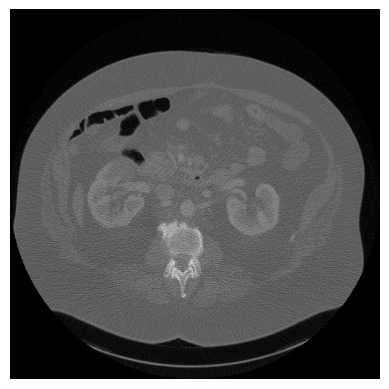

In [2]:
# Import dataset
DIRECTORY = "../"
og_image = import_image(
    DIRECTORY + "/raw/L123/" + "L123_105.raw",
)
print(og_image.size)
plt.imshow(og_image, cmap='gray')
plt.axis('off');

In [3]:
import os
L008 = os.listdir('../raw/L008/')
files = sorted(L008, key=lambda x: int(x.split('_')[1].split('.')[0]))

In [4]:
import numpy as np

def load_raw_image(path, shape=(512, 512), dtype=np.uint16):
    return np.fromfile(path, dtype=dtype).reshape(shape)

images = [load_raw_image(DIRECTORY + "/raw/" + 'L008/' + f) for f in files]

In [5]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import numpy as np

scan = 'L123/'

In [6]:
import numpy as np

def read_raw_image(filepath, shape, dtype):
    data = np.fromfile(filepath, dtype=dtype)
    return data.reshape(shape)

In [7]:
import os
scan = 'L123/'

files = os.listdir('../raw/' + scan)
files = sorted(files, key=lambda x: int(x.split('_')[1].split('.')[0]))

In [8]:
height = 512
width = 512
dtype = np.uint16
folder = "../raw/" + scan

slices = []

for f in files:
    if f.endswith(".raw"):
        img = read_raw_image(
            os.path.join(folder, f),
            shape=(height, width),
            dtype=dtype
        )
        slices.append(img)

volume = np.stack(slices, axis=0)  # shape: (num_slices, height, width)

In [9]:
import stackview
stackview.slice(volume, continuous_update=True, 
                display_min=0, 
                display_max=3000, 
                colormap='gray'
                )

In [11]:
from deepinv.models import DnCNN, DRUNet
import torch

# Load pretrained model
dnCnn = DnCNN(in_channels=1, out_channels=1, pretrained='download').eval()
druNet = DRUNet(in_channels=1, out_channels=1, pretrained='download').eval()

## Using DnCNN

In [11]:
import torch
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = dnCnn.to(device).eval()

batch_size = 16  # try 8, 16, 32 depending on GPU memory
slices = []

batch = []

for i, f in enumerate(files):
    if f.endswith(".raw"):
        img = read_raw_image(
            os.path.join(folder, f),
            shape=(height, width),
            dtype=dtype
        ).astype(np.float32)

        x = torch.from_numpy(img).unsqueeze(0)  # (1, H, W)
        batch.append(x)

        # Run batch when full
        if len(batch) == batch_size:
            x_batch = torch.stack(batch)  # (B, 1, H, W)
            x_batch = x_batch.to(device)

            with torch.no_grad():
                y_batch = model(x_batch)

            y_batch = y_batch.cpu().numpy()

            for y in y_batch:
                slices.append(y.squeeze())

            batch = []  # reset batch

    if i % 10 == 0:
        print(f"{i}/{len(files)} Complete")

# Process leftover batch
if batch:
    x_batch = torch.stack(batch).to(device)
    with torch.no_grad():
        y_batch = model(x_batch)

    for y in y_batch.cpu().numpy():
        slices.append(y.squeeze())

print("Finished")
denoised_volume = np.stack(slices, axis=0)

0/127 Complete
10/127 Complete
20/127 Complete
30/127 Complete
40/127 Complete
50/127 Complete
60/127 Complete
70/127 Complete
80/127 Complete
90/127 Complete
100/127 Complete
110/127 Complete
120/127 Complete
Finished


In [12]:
stackview.slice(denoised_volume, continuous_update=True)

In [13]:
stackview.curtain(volume, denoised_volume, continuous_update=1)

In [14]:
stackview.slice(volume - denoised_volume)

In [15]:
import numpy as np
import stackview

side_by_side = []

for orig, den in zip(volume, denoised_volume):
    combined = np.concatenate([orig, den], axis=1)  # horizontal stack
    side_by_side.append(combined)

side_by_side = np.stack(side_by_side, axis=0)

In [17]:
stackview.slice(side_by_side, zoom_factor=1.5)

In [18]:
diff_slices = []

for orig, den in zip(volume, denoised_volume):
    diff = np.abs(orig - den)
    diff_slices.append(diff)

diff_volume = np.stack(diff_slices, axis=0)

In [19]:
stackview.slice(diff_volume, continuous_update=True, colormap='hot')

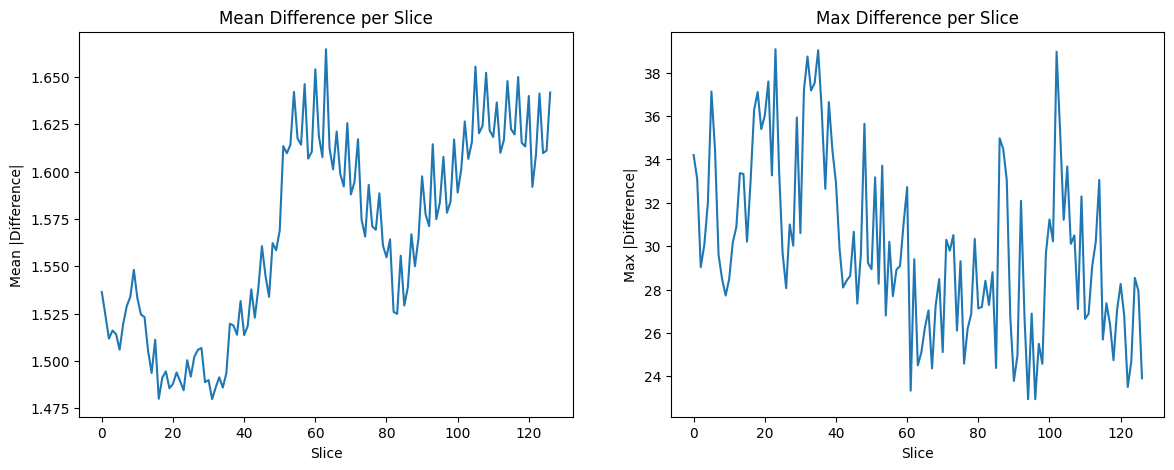

In [20]:
mean_diff = diff_volume.mean(axis=(1, 2))
max_diff = diff_volume.max(axis=(1, 2))
fig, ax  = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(mean_diff)
ax[0].set_title("Mean Difference per Slice")
ax[0].set_xlabel("Slice")
ax[0].set_ylabel("Mean |Difference|")
ax[1].plot(max_diff)
ax[1].set_title("Max Difference per Slice")
ax[1].set_xlabel("Slice")
ax[1].set_ylabel("Max |Difference|")

plt.show()

## Using DruNet

In [12]:
import torch
import numpy as np
import os
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = druNet.to(device).eval()
batch_size = 4  # try 8, 16, 32 depending on GPU memory
slices = []

batch = []

for i, f in enumerate(files):
    if f.endswith(".raw"):
        img = read_raw_image(
            os.path.join(folder, f),
            shape=(height, width),
            dtype=dtype
        ).astype(np.float32)

        x = torch.from_numpy(img).unsqueeze(0)  # (1, H, W)
        batch.append(x)

        # Run batch when full
        if len(batch) == batch_size:
            x_batch = torch.stack(batch)  # (B, 1, H, W)
            x_batch = x_batch.to(device)

            with torch.no_grad():
                y_batch = model(x_batch, sigma=0.1)

            y_batch = y_batch.cpu().numpy()

            for y in y_batch:
                slices.append(y.squeeze())

            batch = []  # reset batch

    if i % 10 == 0:
        print(f"{i}/{len(files)} Complete")

# Process leftover batch
if batch:
    x_batch = torch.stack(batch).to(device)
    with torch.no_grad():
        y_batch = model(x_batch, sigma = 0.1)

    for y in y_batch.cpu().numpy():
        slices.append(y.squeeze())

print("Finished")
denoised_volume = np.stack(slices, axis=0)

0/127 Complete
10/127 Complete
20/127 Complete
30/127 Complete
40/127 Complete
50/127 Complete
60/127 Complete
70/127 Complete
80/127 Complete
90/127 Complete
100/127 Complete
110/127 Complete
120/127 Complete
Finished


In [13]:
stackview.slice(denoised_volume, continuous_update=True)

In [14]:
stackview.curtain(volume, denoised_volume, continuous_update=1)

In [15]:
stackview.slice(volume - denoised_volume)

In [16]:
import numpy as np
import stackview

side_by_side = []

for orig, den in zip(volume, denoised_volume):
    combined = np.concatenate([orig, den], axis=1)  # horizontal stack
    side_by_side.append(combined)

side_by_side = np.stack(side_by_side, axis=0)

In [17]:
stackview.slice(side_by_side, zoom_factor=1.5)

In [18]:
diff_slices = []

for orig, den in zip(volume, denoised_volume):
    diff = np.abs(orig - den)
    diff_slices.append(diff)

diff_volume = np.stack(diff_slices, axis=0)

In [19]:
stackview.slice(diff_volume, continuous_update=True, colormap='hot')

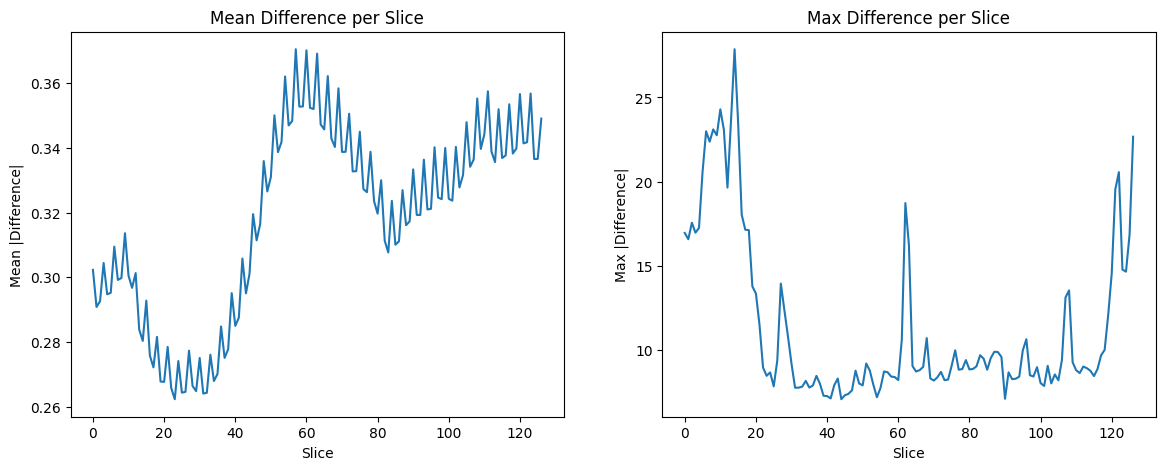

In [20]:
mean_diff = diff_volume.mean(axis=(1, 2))
max_diff = diff_volume.max(axis=(1, 2))
fig, ax  = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(mean_diff)
ax[0].set_title("Mean Difference per Slice")
ax[0].set_xlabel("Slice")
ax[0].set_ylabel("Mean |Difference|")
ax[1].plot(max_diff)
ax[1].set_title("Max Difference per Slice")
ax[1].set_xlabel("Slice")
ax[1].set_ylabel("Max |Difference|")

plt.show()

## Adding out of field artifacts to my pictures